## Spotify Data Analysis Project

This project explores which factors are associated with the popularity of songs on Spotify.

The goal is to understand whether audio features (energy, danceability, valence, etc.) can explain or predict song popularity.

## 1. Import et chargement des données

On importe les bibliothèques nécessaires pour l’analyse de données et la visualisation.

Pandas est utilisé pour manipuler les données sous forme de tableau, et Matplotlib pour créer des graphiques.

Ensuite, on charge le dataset Spotify dans un DataFrame pour commencer l’exploration.

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170653 entries, 0 to 170652
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   valence           170653 non-null  float64
 1   year              170653 non-null  int64  
 2   acousticness      170653 non-null  float64
 3   artists           170653 non-null  object 
 4   danceability      170653 non-null  float64
 5   duration_ms       170653 non-null  int64  
 6   energy            170653 non-null  float64
 7   explicit          170653 non-null  int64  
 8   id                170653 non-null  object 
 9   instrumentalness  170653 non-null  float64
 10  key               170653 non-null  int64  
 11  liveness          170653 non-null  float64
 12  loudness          170653 non-null  float64
 13  mode              170653 non-null  int64  
 14  name              170653 non-null  object 
 15  popularity        170653 non-null  int64  
 16  release_date      17

## 2. Compréhension du dataset

On commence par examiner la structure des données avec la méthode `info()`.

Cela permet de vérifier :
- le nombre de lignes et de colonnes
- les types de variables (numériques ou textuelles)
- la présence éventuelle de valeurs manquantes

Cette étape est essentielle avant toute analyse pour s’assurer que les données sont exploitables.

In [36]:
df_2000 = df[df["year"] >= 2000]
df_2000.shape

(41450, 19)

## 3. Filtrage des données (période moderne)

Pour réduire le biais historique du dataset (musique ancienne vs moderne), nous filtrons les morceaux sortis à partir de l’année 2000.

Cela permet de concentrer l’analyse sur la musique correspondant à l’usage actuel des plateformes de streaming.

In [37]:
corr = df_2000.corr(numeric_only=True)["popularity"].sort_values(ascending=False)
corr

,popularity
popularity,1.000000
year,0.400989
explicit,0.168873
danceability,0.097398
loudness,0.064640
speechiness,0.037911
acousticness,-0.000098
key,-0.003115
valence,-0.015025
tempo,-0.016668


## 4. Analyse des corrélations

Nous calculons ici les corrélations entre la popularité des morceaux et les différentes caractéristiques audio.

L’objectif est d’identifier si certaines variables sont associées à une augmentation ou une diminution de la popularité.

Cette étape permet de repérer les premiers facteurs potentiellement explicatifs.

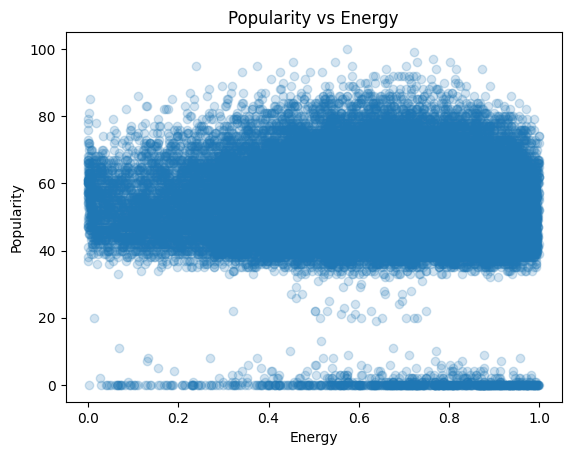

In [38]:
import matplotlib.pyplot as plt

plt.scatter(df_2000["energy"], df_2000["popularity"], alpha=0.2)
plt.title("Popularity vs Energy")
plt.xlabel("Energy")
plt.ylabel("Popularity")
plt.show()

## 5. Visualisation : Popularité vs Energy

Ce graphique montre la relation entre le niveau d’énergie d’un morceau et sa popularité.

Chaque point représente une chanson du dataset.

L’objectif est de visualiser s’il existe une tendance entre ces deux variables.

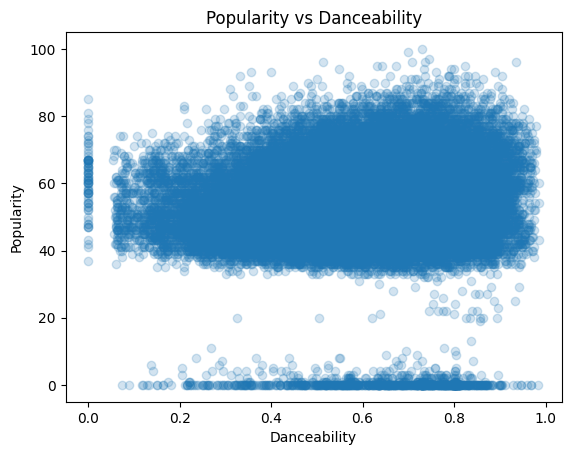

In [39]:
plt.scatter(df_2000["danceability"], df_2000["popularity"], alpha=0.2)
plt.title("Popularity vs Danceability")
plt.xlabel("Danceability")
plt.ylabel("Popularity")
plt.show()

## 6. Visualisation : Popularity vs Danceability

Ce graphique permet d’explorer la relation entre la capacité d’un morceau à être dansant (danceability) et sa popularité.

L’objectif est de vérifier si les morceaux plus dansants sont plus susceptibles d’être populaires.

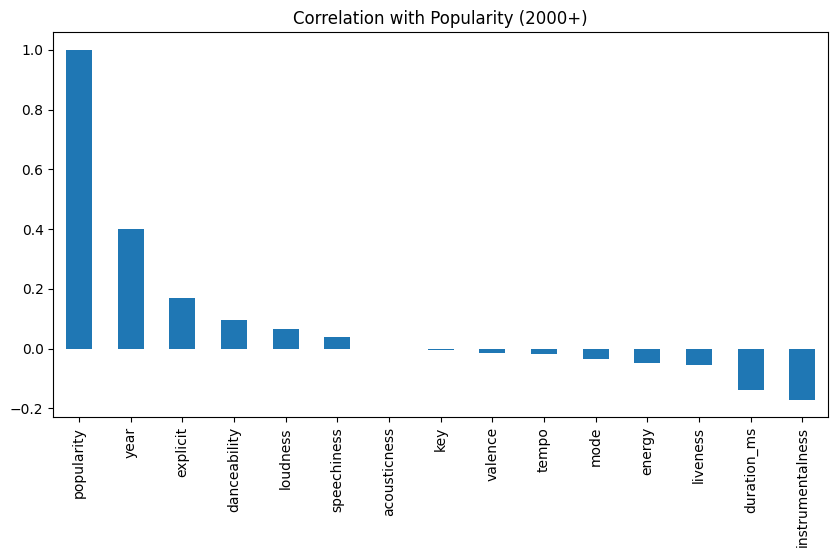

In [40]:
corr = df_2000.corr(numeric_only=True)["popularity"].sort_values(ascending=False)

corr.plot(kind="bar", figsize=(10,5))
plt.title("Correlation with Popularity (2000+)")
plt.show()

## 8. Synthèse des corrélations (2000+)

Ce graphique permet de visualiser l’ensemble des corrélations entre la popularité et les variables audio du dataset.

L’objectif est d’identifier rapidement les variables les plus associées à la popularité et de comparer leur importance relative.

Cela donne une vue d’ensemble plus lisible que les valeurs numériques seules.

## 9. Conclusion

Cette analyse avait pour objectif d’identifier les facteurs associés à la popularité des morceaux sur Spotify.

L’exploration initiale montrait des corrélations relativement fortes entre la popularité et certaines variables comme l’énergie ou l’année de sortie. Cependant, ces relations se sont fortement réduites après filtrage des données et analyse par période.

L’année de sortie apparaît comme le facteur le plus structurant dans les données, suggérant un effet important de la récence et des tendances musicales.

En revanche, les caractéristiques audio (energy, danceability, valence, tempo, etc.) présentent des corrélations faibles avec la popularité et ne permettent pas, à elles seules, de prédire efficacement le succès d’un morceau (R² ≈ 0.04).

Cela indique que la popularité d’un morceau dépend probablement de facteurs externes non présents dans le dataset, tels que les tendances culturelles, les playlists, la promotion ou la viralité.